<a href="https://colab.research.google.com/github/Archi911/Cyclic-traffic-prediction/blob/main/Metro_Interstate_Traffic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Predicting Interstate Traffic Gridlock: An Ensemble Learning Approach
 **Dataset:** UCI Metro Interstate Traffic Volume

Importing libraries and modules

In [44]:
import pandas as pd
import zipfile
import urllib.request
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [35]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [40]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00


In [41]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import optuna
import warnings
warnings.filterwarnings('ignore')

Importing Dataset

In [2]:
# Download the ZIP file directly from UCI
print("Downloading dataset from UCI repository...")
url = "https://archive.ics.uci.edu/static/public/492/metro+interstate+traffic+volume.zip"
urllib.request.urlretrieve(url, "traffic_dataset.zip")

with zipfile.ZipFile("traffic_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
print("Files currently in Colab:", os.listdir())

Files currently in Colab: ['.config', 'Metro_Interstate_Traffic_Volume.csv.gz', 'traffic_dataset.zip', 'sample_data']


###Understanding the Data

In [4]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv.gz', compression='gzip')
display(df.head(15))

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
5,NaN,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,5181
6,NaN,293.17,0.0,0.0,1,Clear,sky is clear,2012-10-02 15:00:00,5584
7,NaN,293.86,0.0,0.0,1,Clear,sky is clear,2012-10-02 16:00:00,6015
8,NaN,294.14,0.0,0.0,20,Clouds,few clouds,2012-10-02 17:00:00,5791
9,NaN,293.10,0.0,0.0,20,Clouds,few clouds,2012-10-02 18:00:00,4770


In [5]:
df.shape

(48204, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [7]:
# Insights
# Missing Data : The `holiday` column shows only 61 non-null values.But it is still significant feature.
# Dates are currently just plain text or object type.
# Categorical Encoding required for features like weather_main and weather_description

In [8]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [10]:
# Insights
# weather conditions are often dry as max times it doesn't rain or snow most of times.
# max reading in rain_1h is 9831 which isn't possible.

###Data Preprocessing

In [24]:
# Remove duplicate rows (if a sensor accidentally recorded the exact same hour twice)
df = df.drop_duplicates()

In [11]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['holiday'] = df['holiday'].fillna('None')

In [13]:
# Fix the 0 Kelvin sensor errors as they point to anomaly
df['temp'] = df['temp'].replace(0, pd.NA)
df['temp'] = df['temp'].ffill()

#  Drop the 9831mm Rain Outlier as they point to anamoly
df = df[df['rain_1h'] < 9000]


✅ Data Cleaning Complete!
Dataset shape after cleaning: (48203, 9)


In [15]:
total_days = df['date_time'].dt.date.nunique()
print(total_days)

1860


Dataset contains about 5 years (1860/365)

---
#### Feature Extraction
Before visualizing temporal trends, we must extract highly granular time features (Hour, Day of Week, Month) from our `date_time` object. This allows us to analyze traffic fluctuations on a micro-level.

In [18]:
# Extracting Time Features for EDA
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['day_name'] = df['date_time'].dt.day_name()

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,year,day_name
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,2012,Tuesday
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,2012,Tuesday
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,2012,Tuesday
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,2012,Tuesday
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,2012,Tuesday


####Exploratory Data Analysis (EDA)
visualizing the features to identify structural traffic patterns

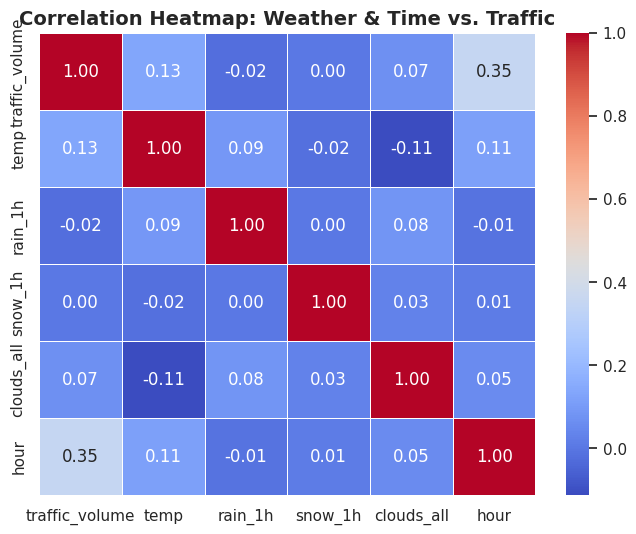

In [21]:
# Correlation Heatmap

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
# selecting only the numeric columns to check correlation
numeric_cols = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Weather & Time vs. Traffic", fontsize=14, fontweight='bold')
plt.show()


The hour and traffic have a high correlation amongst other features.
People have to go to work whether it is raining, snowing, or sunny. The sheer volume of cars doesn't change much based on the weather as heatmap shows temp at 0.13, and rain/snow practically at 0.0

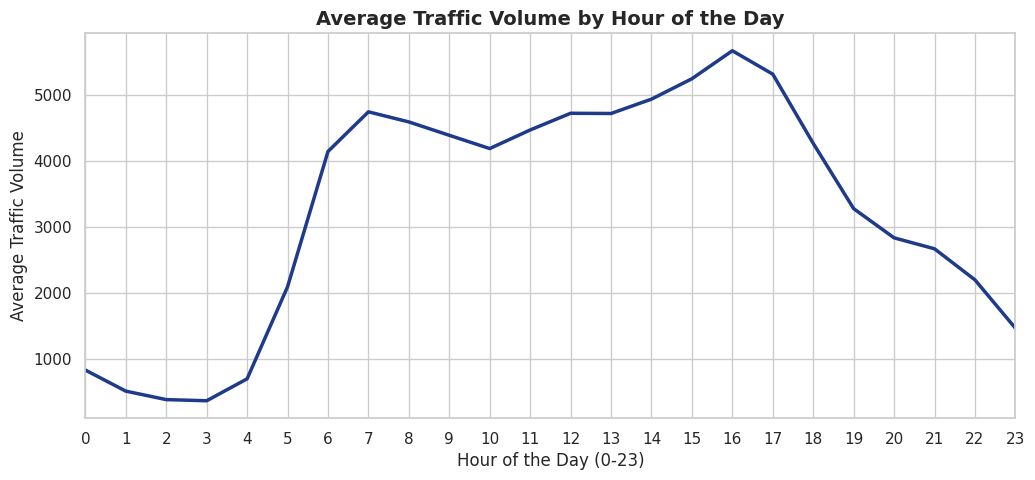

In [22]:
# Hourly Traffic Trend
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df,
    x='hour',
    y='traffic_volume',
    errorbar=None,
    linewidth=2.5,
    color='#1E3A8A'
)
plt.title('Average Traffic Volume by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Traffic Volume', fontsize=12)
plt.xticks(range(0, 24))
plt.xlim(0, 23)
plt.show()

 Traffic is a (Two-peaked) daily routine i.e in morning and evening.
 Traffic sharply spikes around 7:00 AM as commuters head to work and It reaches its absolute maximum peak around 4:00 PM (16:00) as people leave work or travel to home.

EDA depicts that time is a non-linear, cyclical pattern

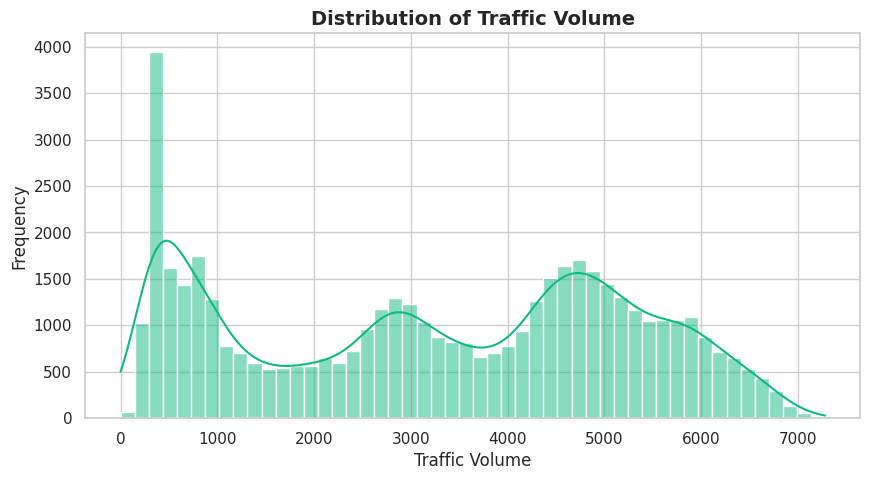

In [23]:
# Target Variable Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['traffic_volume'], bins=50, kde=True, color='#10B981')
plt.title('Distribution of Traffic Volume', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Volume', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Multimodal Distribution as there are three peaks here. Proof that rule-based algorithm like Decision Trees, XGBoost or LightGBM, can be used which can slice the day into specific buckets.

In [27]:
# hours and months must not be treated as linear progressions
# Cyclical Encoding must be used Sine and Cosine transformations, mapping time onto a continuous mathematical circle.
df = df.copy()
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

In [28]:
# Categorical Encoding
# Convert the holiday column into a simple 1 (Yes) or 0 (No) flag
df['is_holiday'] = df['holiday'].apply(lambda x: 0 if x == 'None' else 1)

In [29]:
# One-Hot Encode the weather descriptions
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

In [30]:
cols_to_drop = ['holiday', 'weather_description', 'date_time', 'hour', 'month', 'day_name']
df = df.drop(columns=cols_to_drop, errors='ignore')

###Model Training

In [33]:
# Define Features (X) and Target (y)
X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

# Train-Test Split (80% training, 20% testing)
# Using random_state to get exact same split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# Training to test different regression algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0)
}

print(f"{'Algorithm':<20} | {'R² Score':<10} | {'RMSE (Error in Cars)'}")
print("-" * 55)

# Scoring each model
for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name:<20} | {r2:<10.4f} | {rmse:.2f} cars")

Algorithm            | R² Score   | RMSE (Error in Cars)
-------------------------------------------------------
Linear Regression    | 0.6783     | 1130.92 cars
Ridge Regression     | 0.6783     | 1130.92 cars
Decision Tree        | 0.9411     | 483.97 cars
Random Forest        | 0.9443     | 470.79 cars
XGBoost              | 0.9592     | 402.73 cars
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010705 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 638
[LightGBM] [Info] Number of data points in the train set: 38548, number of used features: 19
[LightGBM] [Info] Start training from score 3256.698791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

###Hyperparameter Optimization (Optuna)

In [42]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        # Keep max_depth relatively low (4 to 8) to prevent overfitting
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }


    model = XGBRegressor(**param)
    model.fit(X_train, y_train)


    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

In [46]:
print("--- Launching Optuna Optimization for XGBoost ---")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\n Optimization Complete!")
print("Best Parameters Found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-24 17:03:27,588] A new study created in memory with name: no-name-61a4ee49-6e3e-4a3e-bfa0-5c8fc89fc8f7


--- Launching Optuna Optimization for XGBoost ---


[I 2026-06-24 17:03:30,263] Trial 0 finished with value: 371.43372978904324 and parameters: {'n_estimators': 213, 'learning_rate': 0.08264408216236974, 'max_depth': 8, 'subsample': 0.8269262596444437, 'colsample_bytree': 0.7002926100927638}. Best is trial 0 with value: 371.43372978904324.
[I 2026-06-24 17:03:32,098] Trial 1 finished with value: 383.17507829320004 and parameters: {'n_estimators': 188, 'learning_rate': 0.03800884960322046, 'max_depth': 8, 'subsample': 0.9089563005678403, 'colsample_bytree': 0.9278234562905631}. Best is trial 0 with value: 371.43372978904324.
[I 2026-06-24 17:03:35,614] Trial 2 finished with value: 414.04941960471336 and parameters: {'n_estimators': 273, 'learning_rate': 0.03227901955549292, 'max_depth': 6, 'subsample': 0.9163732230503386, 'colsample_bytree': 0.7023439251630981}. Best is trial 0 with value: 371.43372978904324.
[I 2026-06-24 17:03:37,824] Trial 3 finished with value: 400.5407282661777 and parameters: {'n_estimators': 394, 'learning_rate': 


 Optimization Complete!
Best Parameters Found:
  n_estimators: 400
  learning_rate: 0.09925088946645556
  max_depth: 8
  subsample: 0.7275726784155104
  colsample_bytree: 0.9546980775774992


###Final Training Of Model

In [47]:
final_xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.09925088946645556,
    max_depth=8,
    subsample=0.7275726784155104,
    colsample_bytree=0.9546980775774992,
    random_state=42,
    n_jobs=-1
)


print("--- Training Final Optimized XGBoost Model ---")
final_xgb.fit(X_train, y_train)
final_preds = final_xgb.predict(X_test)
final_r2 = r2_score(y_test, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print(f" Final R² Score: {final_r2:.4f}")
print(f" Final RMSE: {final_rmse:.2f} cars\n")

--- Training Final Optimized XGBoost Model ---
 Final R² Score: 0.9698
 Final RMSE: 346.61 cars



### Exporting the Model

In [48]:
# Exporting the trained model to a file
model_filename = 'traffic_xgboost_model.joblib'
joblib.dump(final_xgb, model_filename)

print(f" Model successfully saved to {model_filename}")

 Model successfully saved to traffic_xgboost_model.joblib
